# SHAP για το νευρωνικό δίκτυο

Φορτώνει το δίκτυο που αποθήκευσε το `neural_network.ipynb` και εξηγεί τις
προβλέψεις του στα 1142 training μόρια. Καμία εκπαίδευση εδώ.

**Ποιος explainer**: για δίκτυο δεν ισχύει ο `TreeExplainer`, και ο `DeepExplainer`
δεν δουλεύει με Keras 3. Χρησιμοποιείται ο `GradientExplainer` (expected gradients):
προσεγγιστικές τιμές SHAP, στις μονάδες της εξόδου — δηλαδή σε **πιθανότητα High**,
αφού το τελευταίο στρώμα είναι sigmoid. Θετική τιμή σημαίνει ότι ο descriptor
έσπρωξε το μόριο προς High.

Επειδή η πρόβλεψη είναι ο μέσος όρος των δικτύων των seeds, εξηγούνται όλα και οι
τιμές SHAP μέσο-ποιούνται με τον ίδιο τρόπο.

**Προσοχή στη διατύπωση**: οι τιμές είναι προσεγγιστικές και δεν ικανοποιούν
ακριβώς την προσθετικότητα (βασική τιμή + Σ SHAP = πρόβλεψη), όπως στα δενδρικά
μοντέλα. Είναι έγκυρες για κατάταξη σημαντικότητας και για την κατεύθυνση.

**Σε ποια μόρια**: με `DATASET = 'train'` (προεπιλογή) εξηγείται η καθολική
συμπεριφορά του μοντέλου στα 1142 training μόρια. Με `'Test set 1'` ή
`'Test set 2'` εξηγούνται οι προβλέψεις στα external μόρια. Τα αρχεία εξόδου
παίρνουν ανάλογη κατάληξη, οπότε δεν αντικαθιστούν το ένα το άλλο.

Η **αναφορά** του explainer είναι πάντα training μόρια — η συνεισφορά κάθε
descriptor μετριέται σε σχέση με αυτά, ανεξάρτητα από το τι εξηγείται.

**Χρόνος**: ~1 λεπτό.


In [3]:
# ============================== ΠΑΡΑΜΕΤΡΟΙ ==============================
# Προϋπόθεση: έχει τρέξει το neural_network.ipynb για το ίδιο label_case,
# ώστε να υπάρχει το εκπαιδευμένο δίκτυο στο models/mlp_cutoff{50,20}/.
label_case = 'label_cutoff_20%'   # 'label_cutoff_50%' | 'label_cutoff_20%'

# Σε ποια μόρια υπολογίζεται το SHAP:
#   'train'      -> τα 1142 training μόρια (προεπιλογή: η καθολική εικόνα του μοντέλου)
#   'Test set 1' -> τι οδήγησε τις προβλέψεις στα μόρια του Test set 1
#   'Test set 2' -> το ίδιο για το Test set 2
DATASET = 'Test set 1'  # 'train' | 'Test set 1' | 'Test set 2'

RANDOM_STATE = 42
N_BACKGROUND = 200   # μόρια αναφοράς για τον explainer
N_TOP        = 20    # πόσοι descriptors στους πίνακες και τα διαγράμματα


## Υπολογισμός και διαγράμματα

Μοντέλο  : MLP 1×64 + LayerNorm (dropout 0.2, 3 seeds)
           1672 features, εκπαιδευμένο σε 1142 μόρια
Δεδομένα : Test set 1 — 287 μόρια (High=214, Low=73)
Αναφορά  : 200 training μόρια

Υπολογισμός SHAP για 287 μόρια × 1672 descriptors (3 δίκτυα)…
  ολοκληρώθηκε σε 0.2 λεπτά — πίνακας (287, 1672)

=== Top 20 descriptors κατά μέσο |SHAP| — label_cutoff_20%, Test set 1 ===
 rank     descriptor type  mean_abs_shap    κατεύθυνση  cumulative_%
    1      PEOE_VSA9   2D         0.0154  ↑ τιμή → Low        0.4059
    2      PEOE_VSA4   2D         0.0151 ↑ τιμή → High        0.8060
    3       BCUTi-1l   2D         0.0146 ↑ τιμή → High        1.1909
    4          VR1_A   2D         0.0140  ↑ τιμή → Low        1.5611
    5          MAXsF   2D         0.0130 ↑ τιμή → High        1.9040
    6    EState_VSA3   2D         0.0130 ↑ τιμή → High        2.2464
    7      PEOE_VSA5   2D         0.0124 ↑ τιμή → High        2.5734
    8         GATS3s   2D         0.0122 ↑ τιμή → High        2.8961

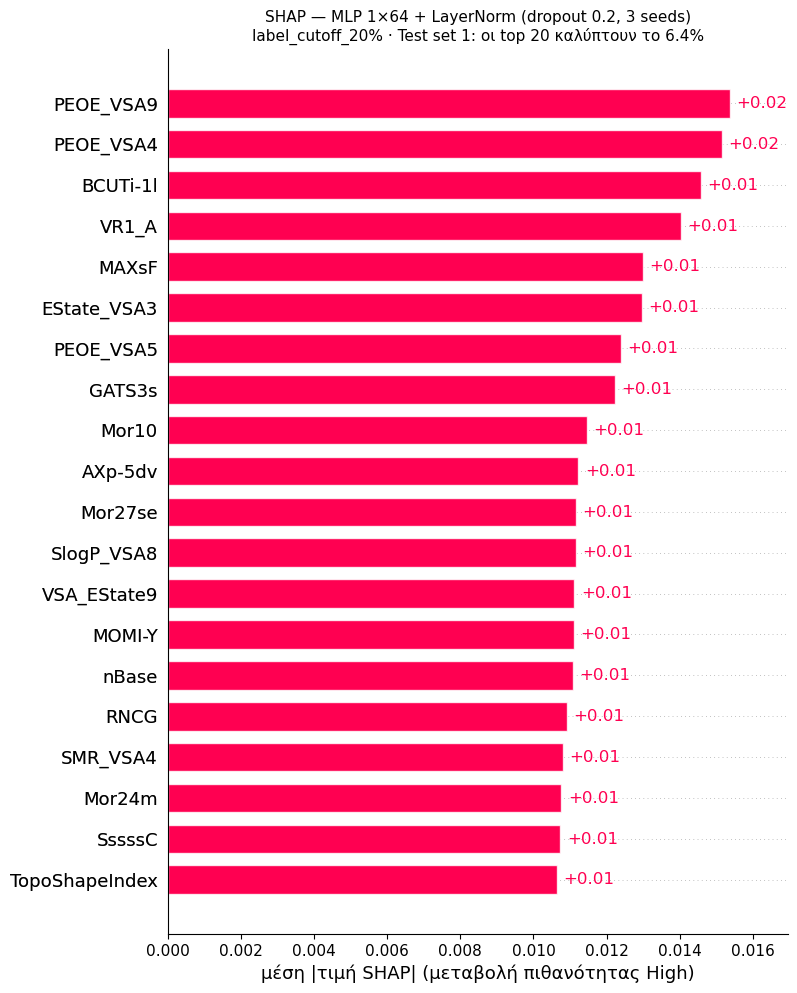

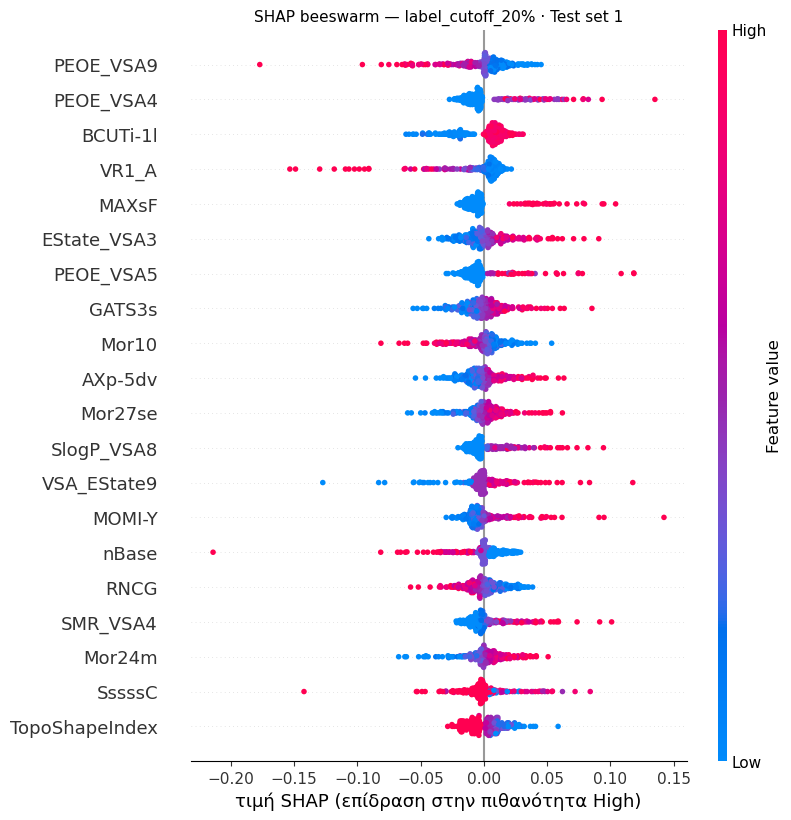

  ../results/Label_cutoff_20%/Neural_network/shap/shap_bar_test1_cutoff20.png
  ../results/Label_cutoff_20%/Neural_network/shap/shap_beeswarm_test1_cutoff20.png


In [4]:
# ==================== SHAP ΓΙΑ ΤΟ ΝΕΥΡΩΝΙΚΟ ΔΙΚΤΥΟ ====================
# Για δίκτυο δεν ισχύει ο TreeExplainer. Χρησιμοποιείται ο GradientExplainer
# (expected gradients): προσεγγιστικές τιμές SHAP, στις μονάδες της εξόδου —
# δηλαδή σε ΠΙΘΑΝΟΤΗΤΑ High, αφού το τελευταίο στρώμα είναι sigmoid.
# Θετική τιμή => ο descriptor έσπρωξε το μόριο προς High.
#
# Εξηγούνται και τα δίκτυα των seeds και οι τιμές μέσο-ποιούνται, όπως ακριβώς
# μέσο-ποιούνται και οι προβλέψεις τους.
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import json
import time
import warnings
import numpy as np
import pandas as pd
import joblib
import keras
import shap
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

warnings.filterwarnings('ignore')

TAG       = label_case.replace('label_cutoff_', '').replace('%', '')
MODEL_DIR = f'../models/mlp_cutoff{TAG}'
OUT       = f'../results/Label_cutoff_{TAG}%/Neural_network/shap'
os.makedirs(OUT, exist_ok=True)

# ------------------------------------------------- το εκπαιδευμένο δίκτυο
_cfile = f'{MODEL_DIR}/config.json'
if not os.path.exists(_cfile):
    raise FileNotFoundError(
        f"Δεν βρέθηκε το {MODEL_DIR}. Τρέξε πρώτα το neural_network.ipynb για {label_case}.")
cfg = json.load(open(_cfile))
prep = joblib.load(f'{MODEL_DIR}/preprocessing.joblib')
features, scaler, clip = prep['features'], prep['scaler'], prep['clip']
models = [keras.models.load_model(f'{MODEL_DIR}/model_seed{s}.keras') for s in cfg['seeds']]

MODEL_NAME = (f"MLP {cfg['n_hidden']}×{cfg['neurons']} + LayerNorm "
              f"(dropout {cfg['dropout']}, {len(cfg['seeds'])} seeds)")
print(f"Μοντέλο  : {MODEL_NAME}")
print(f"           {cfg['n_features']} features, εκπαιδευμένο σε {cfg['n_train']} μόρια")

# ------------------------------------------------------------------ δεδομένα
# Τα training μόρια χρειάζονται πάντα: είναι η αναφορά (background) του explainer,
# δηλαδή το «σε σχέση με τι» μετριέται η συνεισφορά κάθε descriptor.
train = pd.read_csv(f'../Data/merged_df_clean_{label_case}.csv')
train = train[train[label_case].notna()].reset_index(drop=True)

if DATASET == 'train':
    data = train
else:
    _tt = DATASET.replace('Test set ', 'test')
    _lab = (pd.read_excel('../Data/hob_data_set.xlsx', sheet_name=DATASET)
            [['smile', label_case]].rename(columns={'smile': 'SMILES'})
            .drop_duplicates(subset='SMILES'))
    _d = pd.read_csv(f'../Data/{_tt}_descriptors_RAW.csv').drop_duplicates(subset='SMILES')
    data = _d.merge(_lab, on='SMILES', how='inner')
    data = data[data[label_case].notna()].reset_index(drop=True)

X = data[features].apply(pd.to_numeric, errors='coerce').fillna(prep['medians'])
y = data[label_case].astype(int).to_numpy()
Xs = np.clip(scaler.transform(X), -clip, clip).astype('float32')

SUFFIX = 'train' if DATASET == 'train' else DATASET.replace('Test set ', 'test')
print(f"Δεδομένα : {DATASET} — {len(y)} μόρια "
      f"(High={int(y.sum())}, Low={int((y == 0).sum())})")

# ---------------------------------------------------------- υπολογισμός SHAP
_Xtr = np.clip(scaler.transform(train[features]), -clip, clip).astype('float32')
_nbg = min(N_BACKGROUND, len(_Xtr))
_bg = _Xtr[np.random.RandomState(RANDOM_STATE).choice(len(_Xtr), _nbg, replace=False)]
print(f"Αναφορά  : {_nbg} training μόρια")
print(f"\nΥπολογισμός SHAP για {len(Xs)} μόρια × {len(features)} descriptors "
      f"({len(models)} δίκτυα)…")
t0 = time.time()
_vals = []
for m in models:
    sv = shap.GradientExplainer(m, _bg).shap_values(Xs)
    v = np.array(sv[0] if isinstance(sv, list) else sv)
    if v.ndim == 3:
        v = v[..., 0]
    _vals.append(v)
shap_values = np.mean(_vals, axis=0)
print(f"  ολοκληρώθηκε σε {(time.time() - t0) / 60:.1f} λεπτά — πίνακας {shap_values.shape}")

# ---------------------------------------------------- καθολική σημαντικότητα
_rho = []
for j in range(len(features)):
    col = X.iloc[:, j].to_numpy()
    _rho.append(np.nan if np.nanstd(col) == 0 else spearmanr(col, shap_values[:, j]).statistic)

importance = pd.DataFrame({
    'descriptor': features,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0),
    'spearman_value_vs_shap': _rho,
})
importance['κατεύθυνση'] = np.select(
    [importance['spearman_value_vs_shap'] > 0.1, importance['spearman_value_vs_shap'] < -0.1],
    ['↑ τιμή → High', '↑ τιμή → Low'], default='μη μονοτονική')

try:    # 2D ή 3D, από τα μεταδεδομένα του mordred
    from mordred import Calculator, descriptors as _mdesc
    _dims = {str(d): ('3D' if d.require_3D else '2D') for d in Calculator(_mdesc).descriptors}
    importance['type'] = [_dims.get(f, 'Unknown') for f in features]
except Exception as e:
    importance['type'] = 'Unknown'
    print(f"  (το mordred δεν φορτώθηκε — χωρίς 2D/3D: {type(e).__name__})")

importance = importance.sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
importance.insert(0, 'rank', range(1, len(importance) + 1))
importance['cumulative_%'] = (100 * importance['mean_abs_shap'].cumsum()
                              / importance['mean_abs_shap'].sum())
_share = importance['cumulative_%'].iloc[N_TOP - 1]

print(f"\n=== Top {N_TOP} descriptors κατά μέσο |SHAP| — {label_case}, {DATASET} ===")
print(importance.head(N_TOP)[['rank', 'descriptor', 'type', 'mean_abs_shap',
                              'κατεύθυνση', 'cumulative_%']].round(4).to_string(index=False))
print(f"\nΟι top {N_TOP} καλύπτουν το {_share:.1f}% της συνολικής συνεισφοράς "
      f"(από {len(features)} descriptors).")


def _save(df, path):
    try:
        df.to_csv(path, index=False, encoding='utf-8-sig')
        print(f"  {path}")
    except PermissionError:
        print(f"  ⚠ κλειδωμένο, δεν γράφτηκε: {path}")


if (importance['type'] != 'Unknown').any():
    g = importance.groupby('type').agg(descriptors=('descriptor', 'size'),
                                       συνεισφορά=('mean_abs_shap', 'sum'))
    g['% descriptors'] = 100 * g['descriptors'] / g['descriptors'].sum()
    g['% συνεισφοράς'] = 100 * g['συνεισφορά'] / g['συνεισφορά'].sum()
    g['λόγος'] = g['% συνεισφοράς'] / g['% descriptors']
    g[f'στο top-{N_TOP}'] = (importance.head(N_TOP).groupby('type').size()
                             .reindex(g.index).fillna(0).astype(int))
    print(f"\n=== 2D vs 3D ===")
    print(g.round(3).to_string())

print("\nΑποθηκεύτηκαν:")
_save(importance.round(6), f'{OUT}/shap_importance_{SUFFIX}_cutoff{TAG}.csv')
_save(pd.concat([data[['SMILES']], pd.DataFrame(shap_values, columns=features)], axis=1),
      f'{OUT}/shap_values_{SUFFIX}_cutoff{TAG}.csv')
if (importance['type'] != 'Unknown').any():
    _save(g.round(4).reset_index(), f'{OUT}/shap_2d_vs_3d_{SUFFIX}_cutoff{TAG}.csv')

# ---------------------------------------------------------------- διαγράμματα
_top = importance['descriptor'].head(N_TOP).tolist()
_idx = [features.index(d) for d in _top]
expl = shap.Explanation(values=shap_values[:, _idx], base_values=np.zeros(len(Xs)),
                        data=X.iloc[:, _idx].to_numpy(), feature_names=_top)

plt.figure()
shap.plots.bar(expl, max_display=N_TOP, show=False)
plt.title(f'SHAP — {MODEL_NAME}\n{label_case} · {DATASET}: οι top {N_TOP} '
          f'καλύπτουν το {_share:.1f}%', fontsize=11)
plt.xlabel('μέση |τιμή SHAP| (μεταβολή πιθανότητας High)')
plt.gcf().savefig(f'{OUT}/shap_bar_{SUFFIX}_cutoff{TAG}.png', dpi=200, bbox_inches='tight')
plt.show()

plt.figure()
shap.plots.beeswarm(expl, max_display=N_TOP, show=False)
plt.title(f'SHAP beeswarm — {label_case} · {DATASET}', fontsize=11)
plt.xlabel('τιμή SHAP (επίδραση στην πιθανότητα High)')
plt.gcf().savefig(f'{OUT}/shap_beeswarm_{SUFFIX}_cutoff{TAG}.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"  {OUT}/shap_bar_{SUFFIX}_cutoff{TAG}.png\n  {OUT}/shap_beeswarm_{SUFFIX}_cutoff{TAG}.png")
